# Etna Cause-Trigger Analysis

This notebook applies the Cause-Trigger workflow to the Etna 2008 case study. The full dataset is loaded as the constructed data product, but the algorithm is run only on a fixed case-study interval around the Wenchuan teleseismic arrival.

The split into \(I_1\) and \(I_2\) is selected automatically from the effect variable. The known event time is shown only for physical interpretation.

## 1. Imports, paths, and case-study interval

In [5]:
from pathlib import Path
import sys
import warnings
import pandas as pd

warnings.filterwarnings("ignore", message="No frequency information was provided")
warnings.filterwarnings("ignore", message="A date index has been provided")
warnings.filterwarnings("ignore", message="invalid value encountered")
warnings.filterwarnings("ignore", message="An input array is constant")

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 40)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "etna"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_etna import (
    COMPACT_RUN_SPECS,
    DEFAULT_RUN_SPECS,
    EFFECT,
    EtnaWorkflowConfig,
    case_study_interval,
    compact_grid_errors,
    compact_grid_outputs,
    expand_pair_outputs,
    load_model_frame,
    model_overview,
    plot_effect_with_split,
    reference_parameter_table,
    run_sensitivity_grid,
    split_diagnostics,
)

ETNA_PATH = DATA_DIR / "etna_final.csv"
EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

In [ ]:
CASE_PRE_DAYS = 14
CASE_POST_HOURS = 72
MIN_I1_LENGTH = 168
MIN_I2_LENGTH = 72
MAX_LAGS = 12
run_specs = DEFAULT_RUN_SPECS # "DEFAULT_RUN_SPECS" or "COMPACT_RUN_SPECS". compact considers tau=0 contemporaneous trigger candidates

X_full = load_model_frame(ETNA_PATH)
X = case_study_interval(
    X_full,
    EVENT_TIME,
    pre_days=CASE_PRE_DAYS,
    post_hours=CASE_POST_HOURS,
)

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,408,8,2008-04-28 07:00:00+00:00,2008-05-15 06:00:00+00:00,h,local_event_rate_anomaly_scaled,-0.286207,-0.286207,0.122272,9.779688,0.627344,0.0,7


## 2. Reference parameters and split audit

This section reports two checks before running the causal backends.

`reference_parameters` shows the VAR-AIC and VAR-BIC lag suggestions. These are metadata only; they do not select the final interpretation.

`split_diagnostics` shows the automatic Cause-Trigger split: `split_time`, lengths of \(I_1\) and \(I_2\), the target mean change, distance to the known event time, and whether the split is a boundary artefact.

,effect,selected_lag,selected_distribution,lag_method,max_lags,fallback_lag,fallback_distribution
0,local_event_rate_anomaly_scaled,7,gaussian,VAR-AIC,12,1,gaussian
1,local_event_rate_anomaly_scaled,1,gaussian,VAR-BIC,12,1,gaussian


,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split,split_end_index,split_end_time,split_score,signed_mean_I1,signed_mean_I2
0,local_event_rate_anomaly_scaled,336,2008-05-12 07:00:00+00:00,336,72,0.00887,0.734266,0.725396,2008-05-12 06:28:00+00:00,0 days 00:32:00,True,408,2008-05-15 06:00:00+00:00,0.725396,-0.00887,0.734266


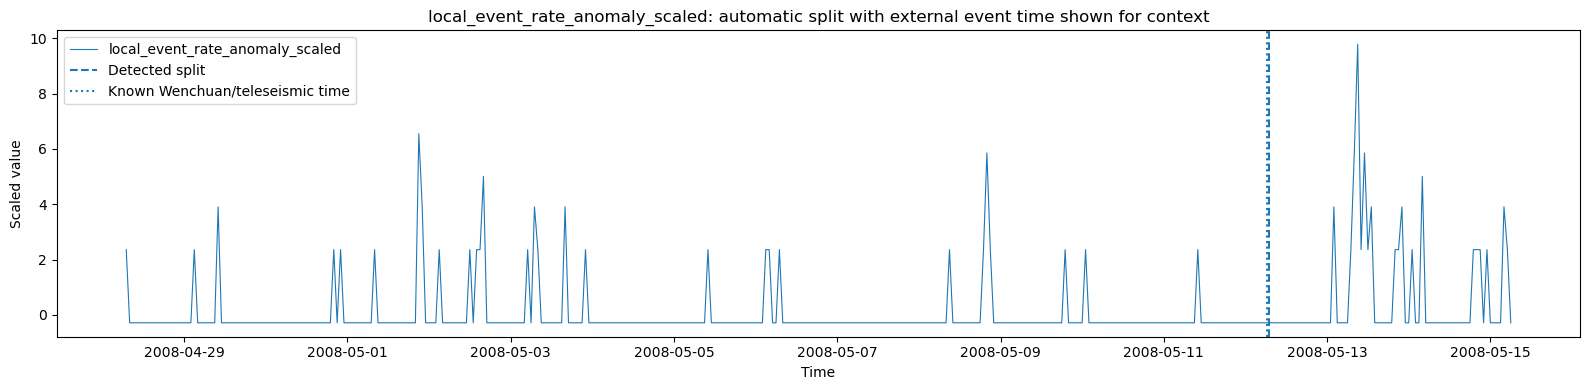

In [7]:
reference_parameters = reference_parameter_table(
    X,
    EFFECT,
    max_lags=MAX_LAGS,
    fallback_lag=1,
    fallback_distribution="gaussian",
)
display(reference_parameters)

selected_lag = int(reference_parameters.loc[
    reference_parameters["lag_method"].eq("VAR-AIC"),
    "selected_lag"
].iloc[0])

workflow = EtnaWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    alpha=0.05,
    selected_lag=selected_lag,
    max_lags=MAX_LAGS,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    distribution="gaussian",
    parameter_source="reference_metadata",
    run_specs=run_specs,
)

split_row = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([split_row]))

plot_effect_with_split(
    X,
    EFFECT,
    split_row,
    event_time=EVENT_TIME,
)

## 3. Backend and lag grid

This section runs HMML, PCMCI, and PCMCI+ over max_lags.

The first table expands accepted cause-trigger pairs into one row per pair. The second table keeps rows with any backend signal: non-empty \(B_2\), trigger candidates, accepted triggers, accepted pairs, or PCMCI+ contemporaneous links.

Main columns: `B_2` = selected lagged parents of the effect; `trigger_candidates` = variables eligible for moderation testing; `accepted_triggers` = candidates passing the F-test; `pairs` = final cause-trigger pairs.

In [8]:
grid_all = run_sensitivity_grid(
    X,
    workflow,
    run_specs=run_specs,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="robust_parcorr",
)

pair_rows = expand_pair_outputs(grid_all)
signal_rows = compact_grid_outputs(grid_all, mode="signals")
error_rows = compact_grid_errors(grid_all)

print(f"All grid rows: {len(grid_all)}")
print(f"Rows with accepted pairs: {len(pair_rows)}")
print(f"Rows with any backend signal: {len(signal_rows)}")
print(f"Rows with backend errors: {len(error_rows)}")

display(pair_rows)
display(signal_rows)

if not error_rows.empty:
    display(error_rows)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\regression\_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\regression\_too

All grid rows: 36
Rows with accepted pairs: 4
Rows with any backend signal: 29
Rows with backend errors: 0


,backend,run,lag,distribution,cause,trigger,split_timestamp,I1_length,I2_length,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links
0,hmml,hmml_backend_beta,1,gaussian,API_scaled,background_seismic_scaled,2008-05-12 07:00:00+00:00,336,72,0.000006,0.261251,0
1,hmml,hmml_backend_beta,1,gaussian,CO2_3_scaled,API_scaled,2008-05-12 07:00:00+00:00,336,72,0.000006,0.261251,0
2,hmml,hmml_backend_beta,10,gaussian,CO2_SO2_scaled,API_scaled,2008-05-12 07:00:00+00:00,336,72,0.005061,0.125672,0
3,hmml,hmml_backend_beta,11,gaussian,teleseismic_scaled,API_scaled,2008-05-12 07:00:00+00:00,336,72,0.001233,0.166019,0


,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
0,hmml_backend_beta,hmml,1,gaussian,2008-05-12 07:00:00+00:00,336,72,"[teleseismic_scaled, background_seismic_scaled, CO2_3_scaled, pressure_drop_scaled, WindSpeed_scaled, API_scaled, CO2_SO2_scaled]","[teleseismic_scaled, background_seismic_scaled, CO2_3_scaled, API_scaled]","[teleseismic_scaled, background_seismic_scaled, CO2_3_scaled, API_scaled]",[],"[background_seismic_scaled, API_scaled]","[API_scaled, CO2_3_scaled]","[(API_scaled, background_seismic_scaled), (CO2_3_scaled, API_scaled)]",0.000006,0.261251,0,None
1,hmml_backend_beta,hmml,4,gaussian,2008-05-12 07:00:00+00:00,336,72,[CO2_3_scaled],[CO2_3_scaled],[CO2_3_scaled],[],[],[],[],NaN,NaN,0,None
2,hmml_backend_beta,hmml,5,gaussian,2008-05-12 07:00:00+00:00,336,72,[CO2_3_scaled],[CO2_3_scaled],[CO2_3_scaled],[],[],[],[],NaN,NaN,0,None
3,hmml_backend_beta,hmml,6,gaussian,2008-05-12 07:00:00+00:00,336,72,[CO2_3_scaled],[CO2_3_scaled],[CO2_3_scaled],[],[],[],[],NaN,NaN,0,None
4,hmml_backend_beta,hmml,7,gaussian,2008-05-12 07:00:00+00:00,336,72,[CO2_3_scaled],[CO2_3_scaled],[CO2_3_scaled],[],[],[],[],NaN,NaN,0,None
5,hmml_backend_beta,hmml,8,gaussian,2008-05-12 07:00:00+00:00,336,72,[API_scaled],[API_scaled],[API_scaled],[],[],[],[],NaN,NaN,0,None
6,hmml_backend_beta,hmml,9,gaussian,2008-05-12 07:00:00+00:00,336,72,[API_scaled],[API_scaled],[API_scaled],[],[],[],[],NaN,NaN,0,None
7,hmml_backend_beta,hmml,10,gaussian,2008-05-12 07:00:00+00:00,336,72,"[teleseismic_scaled, pressure_drop_scaled, WindSpeed_scaled, API_scaled, CO2_SO2_scaled]","[teleseismic_scaled, API_scaled]","[teleseismic_scaled, API_scaled]",[],[API_scaled],[CO2_SO2_scaled],"[(CO2_SO2_scaled, API_scaled)]",0.005061,0.125672,0,None
8,hmml_backend_beta,hmml,11,gaussian,2008-05-12 07:00:00+00:00,336,72,"[teleseismic_scaled, pressure_drop_scaled, WindSpeed_scaled, API_scaled]","[teleseismic_scaled, API_scaled]","[teleseismic_scaled, API_scaled]",[],[API_scaled],[teleseismic_scaled],"[(teleseismic_scaled, API_scaled)]",0.001233,0.166019,0,None
9,hmml_backend_beta,hmml,12,gaussian,2008-05-12 07:00:00+00:00,336,72,"[background_seismic_scaled, CO2_3_scaled, WindSpeed_scaled, CO2_SO2_scaled]","[background_seismic_scaled, CO2_3_scaled]","[background_seismic_scaled, CO2_3_scaled]",[],[],[],[],0.075568,0.054352,0,None
